In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from glob import glob
import random


# Set random seed for reproducibility
manualSeed = 12

print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True) # Needed for reproducible results
torch.backends.cudnn.deterministic = True
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

Random Seed:  12


## Dataset Introduction
This dataset contains two sets.

The first set is all goods, the second set contains goods and defective products.

You need to classify the products into defective ones or not, and calculate the accuracy.

The benchmark is accuracy.

In [2]:
image_size = 256
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print("[INFO] Current device:", torch.cuda.get_device_name(torch.cuda.current_device()), f", device num:{torch.cuda.current_device()}")
elif torch.has_mps:
    device = 'mps'
    print("[INFO] Current device: MAC OS Metal Performance Shaders.")
else:
    device = 'cpu'
    print("[INFO] Current device: CPU")
    print("*"*50,"\n[WARNING] You may need to change the device to GPU or MPS to get better performance.")
    print("*"*50)
device = torch.device(device)

[INFO] Current device: Tesla V100-PCIE-32GB , device num:0


In [4]:
# Improved VAE model
class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # 256 -> 128
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(inplace=True),
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(512 * 8 * 8, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 512 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(inplace=True),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),    # 128 -> 256
            nn.Tanh()  # Output range [-1, 1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_enc = self.encoder(x)  # [batch_size, 512, 8, 8]
        x_enc_flat = x_enc.view(x_enc.size(0), -1)
        mu = self.fc_mu(x_enc_flat)
        logvar = self.fc_logvar(x_enc_flat)
        z = self.reparameterize(mu, logvar)
        x_dec_input = self.decoder_input(z)
        x_dec_input = x_dec_input.view(-1, 512, 8, 8)
        x_recon = self.decoder(x_dec_input)
        return x_recon, mu, logvar

In [5]:
from torchsummary import summary

vae = VAE(latent_dim=256)

print("Encoder:")
summary(vae.encoder, input_size=(3, 256, 256))

print("\nDecoder:")
summary(vae.decoder, input_size=(512, 8, 8))

Encoder:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           3,136
       BatchNorm2d-2         [-1, 64, 128, 128]             128
         LeakyReLU-3         [-1, 64, 128, 128]               0
            Conv2d-4          [-1, 128, 64, 64]         131,200
       BatchNorm2d-5          [-1, 128, 64, 64]             256
         LeakyReLU-6          [-1, 128, 64, 64]               0
            Conv2d-7          [-1, 256, 32, 32]         524,544
       BatchNorm2d-8          [-1, 256, 32, 32]             512
         LeakyReLU-9          [-1, 256, 32, 32]               0
           Conv2d-10          [-1, 512, 16, 16]       2,097,664
      BatchNorm2d-11          [-1, 512, 16, 16]           1,024
        LeakyReLU-12          [-1, 512, 16, 16]               0
           Conv2d-13            [-1, 512, 8, 8]       4,194,816
      BatchNorm2d-14          

In [6]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum') / x.shape[0]
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return recon_loss + beta * kl_divergence

In [7]:

def train_vae(model, train_loader, val_loader, optimizer, epochs=100):
    # Use ReduceLROnPlateau scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=7, verbose=True, min_lr=5e-5)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = loss_function(recon_batch, data, mu, logvar, beta=1)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(device)
                recon_batch, mu, logvar = model(data)
                loss = loss_function(recon_batch, data, mu, logvar, beta=1)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Adjust learning rate
        scheduler.step(val_loss)

        print(f'Epoch: {epoch + 1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    return train_losses, val_losses


def test_image(img, vae, device):
    img = img.to(device)
    vae.eval()
    with torch.no_grad():
        recon, mu, log_var = vae(img.unsqueeze(0))
        loss = nn.functional.mse_loss(recon, img.unsqueeze(0), reduction='mean')
        return loss.item()


def calculate_separate_accuracy(good_losses, defective_losses):
    # Use ROC curve to find optimal threshold
    from sklearn.metrics import roc_curve, auc

    labels = [0]*len(good_losses) + [1]*len(defective_losses)
    scores = good_losses + defective_losses

    fpr, tpr, thresholds = roc_curve(labels, scores)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Compute accuracies
    good_correct = sum(loss < optimal_threshold for loss in good_losses)
    good_accuracy = good_correct / len(good_losses)

    defective_correct = sum(loss >= optimal_threshold for loss in defective_losses)
    defective_accuracy = defective_correct / len(defective_losses)

    overall_accuracy = (good_correct + defective_correct) / (len(good_losses) + len(defective_losses))

    return good_accuracy, defective_accuracy, overall_accuracy

# Custom dataset
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, folder_path, transform=None):
        self.image_paths = glob(os.path.join(folder_path, "*.png"))  # Get all images in the folder
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0  # Second value is a placeholder label


In [8]:
overall_accuracy = []

## For category "bottle"

In [ ]:
category = 'bottle'
print(f"\nProcessing category: {category}")

# Load training and validation datasets
train_dataset = CustomImageDataset(folder_path=f'./data/train/{category}', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = CustomImageDataset(folder_path=f'./data/val/{category}', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

print("train: ", len(train_dataset))
print("val: ", len(val_dataset))

# Initialize model and optimizer
latent_dim = 256
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=9e-5, weight_decay=1e-5)


# Train the model
train_losses, val_losses = train_vae(model, train_loader, val_loader, optimizer, epochs=150)


# Evaluate the model
test_good_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/good', transform=transform)
test_defective_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/error', transform=transform)

test_good_loader = DataLoader(test_good_dataset, batch_size=1, shuffle=False)
test_defective_loader = DataLoader(test_defective_dataset, batch_size=1, shuffle=False)

# Compute losses for good samples
good_losses = []
for data, _ in test_good_loader:
    loss = test_image(data.squeeze(0), model, device)
    good_losses.append(loss)

# Compute losses for defective samples
defective_losses = []
for data, _ in test_defective_loader:
    loss = test_image(data.squeeze(0), model, device)
    defective_losses.append(loss)

# Compute accuracies
good_acc, defective_acc, overall_acc = calculate_separate_accuracy(good_losses, defective_losses)
print(f"{category} Good Accuracy: {good_acc * 100:.2f}%")
print(f"{category} Defective Accuracy: {defective_acc * 100:.2f}%")
print(f"{category} Overall Accuracy: {overall_acc * 100:.2f}%")

overall_accuracy.append(overall_acc)


Processing category: bottle
train:  167
val:  42
Epoch: 1 | Train Loss: 148316.7292 | Val Loss: 102064.2266 | LR: 0.000090
Epoch: 2 | Train Loss: 99249.5052 | Val Loss: 102079.8984 | LR: 0.000090
Epoch: 3 | Train Loss: 65766.0729 | Val Loss: 102658.4219 | LR: 0.000090
Epoch: 4 | Train Loss: 44772.7344 | Val Loss: 104815.0938 | LR: 0.000090
Epoch: 5 | Train Loss: 31338.2363 | Val Loss: 109714.7969 | LR: 0.000090
Epoch: 6 | Train Loss: 23252.7617 | Val Loss: 111859.9297 | LR: 0.000090
Epoch: 7 | Train Loss: 18282.6270 | Val Loss: 94564.6797 | LR: 0.000090
Epoch: 8 | Train Loss: 15172.5072 | Val Loss: 63816.5039 | LR: 0.000090
Epoch: 9 | Train Loss: 13201.6305 | Val Loss: 28641.7871 | LR: 0.000090
Epoch: 10 | Train Loss: 11795.2633 | Val Loss: 14231.0303 | LR: 0.000090
Epoch: 11 | Train Loss: 10719.2018 | Val Loss: 11962.7598 | LR: 0.000090
Epoch: 12 | Train Loss: 9797.5518 | Val Loss: 12946.0371 | LR: 0.000090
Epoch: 13 | Train Loss: 9069.4440 | Val Loss: 10277.2412 | LR: 0.000090
Epoch

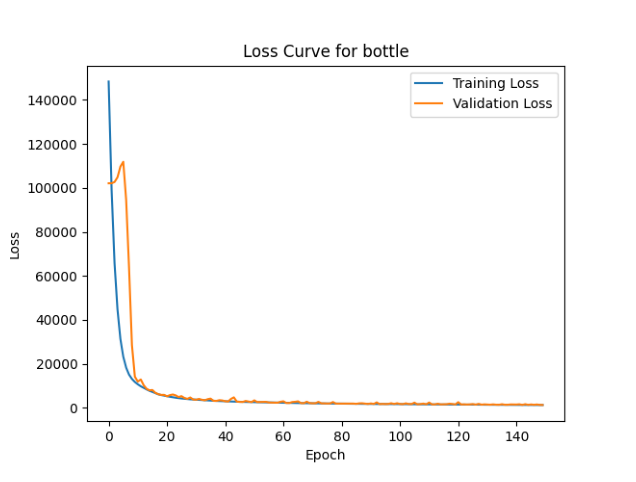

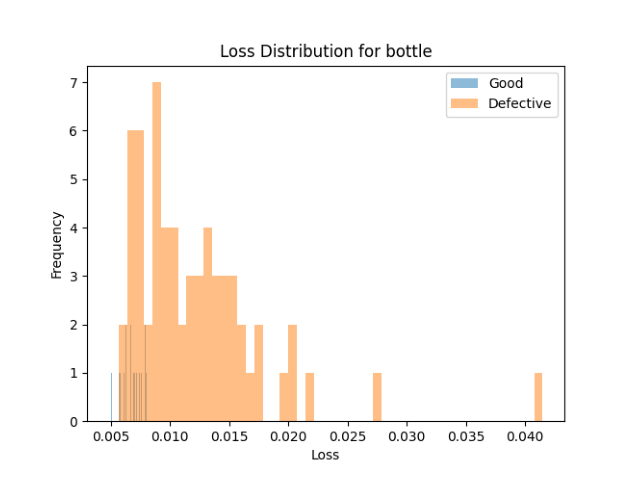

In [ ]:
# Plot and save loss curves
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve for {category}')
plt.show()
plt.close()


# Plot and save loss distributions
plt.figure()
plt.hist(good_losses, bins=50, alpha=0.5, label='Good')
plt.hist(defective_losses, bins=50, alpha=0.5, label='Defective')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'Loss Distribution for {category}')
plt.show()
plt.close()


## For category "cable"

In [ ]:
category = 'cable'
print(f"\nProcessing category: {category}")

# Load training and validation datasets
train_dataset = CustomImageDataset(folder_path=f'./data/train/{category}', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = CustomImageDataset(folder_path=f'./data/val/{category}', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

print("train: ", len(train_dataset))
print("val: ", len(val_dataset))

# Initialize model and optimizer
latent_dim = 256
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1.2e-4, weight_decay=1e-5)


# Train the model
train_losses, val_losses = train_vae(model, train_loader, val_loader, optimizer, epochs=150)


# Evaluate the model
test_good_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/good', transform=transform)
test_defective_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/error', transform=transform)

test_good_loader = DataLoader(test_good_dataset, batch_size=1, shuffle=False)
test_defective_loader = DataLoader(test_defective_dataset, batch_size=1, shuffle=False)

# Compute losses for good samples
good_losses = []
for data, _ in test_good_loader:
    loss = test_image(data.squeeze(0), model, device)
    good_losses.append(loss)

# Compute losses for defective samples
defective_losses = []
for data, _ in test_defective_loader:
    loss = test_image(data.squeeze(0), model, device)
    defective_losses.append(loss)

# Compute accuracies
good_acc, defective_acc, overall_acc = calculate_separate_accuracy(good_losses, defective_losses)
print(f"{category} Good Accuracy: {good_acc * 100:.2f}%")
print(f"{category} Defective Accuracy: {defective_acc * 100:.2f}%")
print(f"{category} Overall Accuracy: {overall_acc * 100:.2f}%")

overall_accuracy.append(overall_acc)



Processing category: cable
train:  179
val:  45


/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch: 1 | Train Loss: 94464.5599 | Val Loss: 46635.2109 | LR: 0.000120
Epoch: 2 | Train Loss: 65263.0573 | Val Loss: 45710.9023 | LR: 0.000120
Epoch: 3 | Train Loss: 40803819384.5586 | Val Loss: 44060.5195 | LR: 0.000120
Epoch: 4 | Train Loss: 38111.2070 | Val Loss: 40964.0352 | LR: 0.000120
Epoch: 5 | Train Loss: 30198.4277 | Val Loss: 38095.4766 | LR: 0.000120
Epoch: 6 | Train Loss: 25512.5560 | Val Loss: 36009.0664 | LR: 0.000120
Epoch: 7 | Train Loss: 22501.4303 | Val Loss: 34868.5117 | LR: 0.000120
Epoch: 8 | Train Loss: 20349.1855 | Val Loss: 34628.2695 | LR: 0.000120
Epoch: 9 | Train Loss: 18595.8789 | Val Loss: 35040.4102 | LR: 0.000120
Epoch: 10 | Train Loss: 17290.2767 | Val Loss: 35800.4805 | LR: 0.000120
Epoch: 11 | Train Loss: 16152.9359 | Val Loss: 36678.0117 | LR: 0.000120
Epoch: 12 | Train Loss: 15244.9414 | Val Loss: 37559.1523 | LR: 0.000120
Epoch: 13 | Train Loss: 14441.3066 | Val Loss: 38442.5508 | LR: 0.000120
Epoch: 14 | Train Loss: 13775.4600 | Val Loss: 39196.7

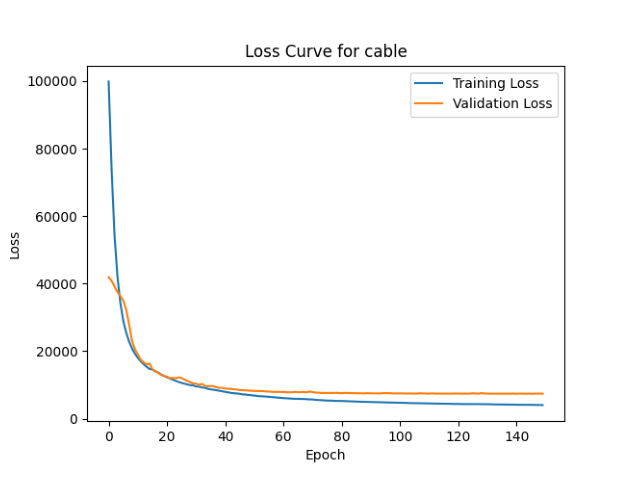

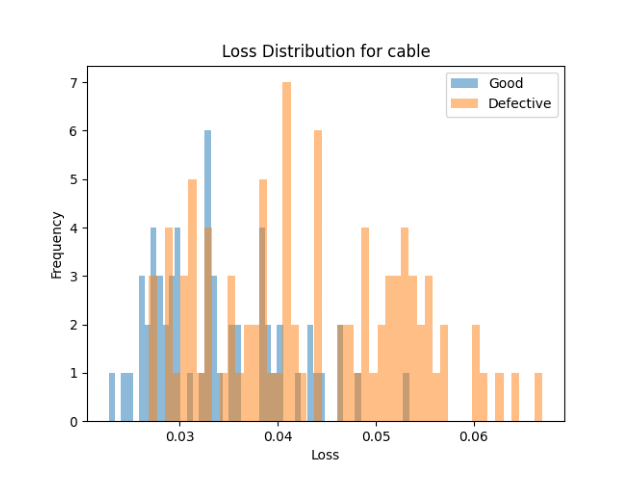

In [ ]:
# Plot and save loss curves
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve for {category}')
plt.show()
plt.close()


# Plot and save loss distributions
plt.figure()
plt.hist(good_losses, bins=50, alpha=0.5, label='Good')
plt.hist(defective_losses, bins=50, alpha=0.5, label='Defective')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'Loss Distribution for {category}')
plt.show()
plt.close()


## For category "capsule"

In [ ]:
category = 'capsule'
print(f"\nProcessing category: {category}")

# Load training and validation datasets
train_dataset = CustomImageDataset(folder_path=f'./data/train/{category}', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = CustomImageDataset(folder_path=f'./data/val/{category}', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

print("train: ", len(train_dataset))
print("val: ", len(val_dataset))

# Initialize model and optimizer
latent_dim = 512
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


# Train the model
train_losses, val_losses = train_vae(model, train_loader, val_loader, optimizer, epochs=150)


# Evaluate the model
test_good_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/good', transform=transform)
test_defective_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/error', transform=transform)

test_good_loader = DataLoader(test_good_dataset, batch_size=1, shuffle=False)
test_defective_loader = DataLoader(test_defective_dataset, batch_size=1, shuffle=False)

# Compute losses for good samples
good_losses = []
for data, _ in test_good_loader:
    loss = test_image(data.squeeze(0), model, device)
    good_losses.append(loss)

# Compute losses for defective samples
defective_losses = []
for data, _ in test_defective_loader:
    loss = test_image(data.squeeze(0), model, device)
    defective_losses.append(loss)

# Compute accuracies
good_acc, defective_acc, overall_acc = calculate_separate_accuracy(good_losses, defective_losses)
print(f"{category} Good Accuracy: {good_acc * 100:.2f}%")
print(f"{category} Defective Accuracy: {defective_acc * 100:.2f}%")
print(f"{category} Overall Accuracy: {overall_acc * 100:.2f}%")

overall_accuracy.append(overall_acc)



Processing category: capsule
train:  175
val:  44
Epoch: 1 | Train Loss: 132839.4115 | Val Loss: 74326.6094 | LR: 0.000100
Epoch: 2 | Train Loss: 93708.4505 | Val Loss: 71725.2266 | LR: 0.000100
Epoch: 3 | Train Loss: 58218.3997 | Val Loss: 66542.0391 | LR: 0.000100
Epoch: 4 | Train Loss: 38245.8893 | Val Loss: 57546.7812 | LR: 0.000100
Epoch: 5 | Train Loss: 27844.1406 | Val Loss: 45238.1094 | LR: 0.000100
Epoch: 6 | Train Loss: 22104.3743 | Val Loss: 33473.9180 | LR: 0.000100
Epoch: 7 | Train Loss: 18556.2292 | Val Loss: 25419.0703 | LR: 0.000100
Epoch: 8 | Train Loss: 16220.8685 | Val Loss: 20386.1621 | LR: 0.000100
Epoch: 9 | Train Loss: 14351.7165 | Val Loss: 16536.4062 | LR: 0.000100
Epoch: 10 | Train Loss: 12765.0189 | Val Loss: 15652.6777 | LR: 0.000100
Epoch: 11 | Train Loss: 11426.6465 | Val Loss: 12245.3955 | LR: 0.000100
Epoch: 12 | Train Loss: 10138.7188 | Val Loss: 10360.2305 | LR: 0.000100
Epoch: 13 | Train Loss: 9187.0934 | Val Loss: 10470.3145 | LR: 0.000100
Epoch: 14

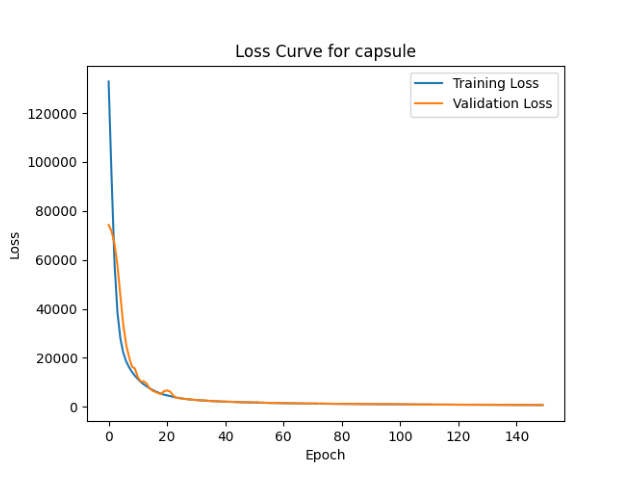

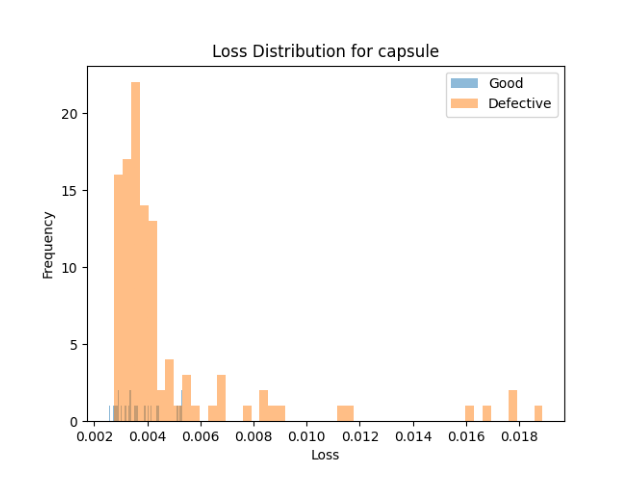

In [ ]:
# Plot and save loss curves
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve for {category}')
plt.show()
plt.close()


# Plot and save loss distributions
plt.figure()
plt.hist(good_losses, bins=50, alpha=0.5, label='Good')
plt.hist(defective_losses, bins=50, alpha=0.5, label='Defective')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'Loss Distribution for {category}')
plt.show()
plt.close()


## For category "pill"

In [ ]:
category = 'pill'
print(f"\nProcessing category: {category}")

# Load training and validation datasets
train_dataset = CustomImageDataset(folder_path=f'./data/train/{category}', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = CustomImageDataset(folder_path=f'./data/val/{category}', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

print("train: ", len(train_dataset))
print("val: ", len(val_dataset))

# Initialize model and optimizer
latent_dim = 256
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


# Train the model
train_losses, val_losses = train_vae(model, train_loader, val_loader, optimizer, epochs=150)


# Evaluate the model
test_good_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/good', transform=transform)
test_defective_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/error', transform=transform)

test_good_loader = DataLoader(test_good_dataset, batch_size=1, shuffle=False)
test_defective_loader = DataLoader(test_defective_dataset, batch_size=1, shuffle=False)

# Compute losses for good samples
good_losses = []
for data, _ in test_good_loader:
    loss = test_image(data.squeeze(0), model, device)
    good_losses.append(loss)

# Compute losses for defective samples
defective_losses = []
for data, _ in test_defective_loader:
    loss = test_image(data.squeeze(0), model, device)
    defective_losses.append(loss)

# Compute accuracies
good_acc, defective_acc, overall_acc = calculate_separate_accuracy(good_losses, defective_losses)
print(f"{category} Good Accuracy: {good_acc * 100:.2f}%")
print(f"{category} Defective Accuracy: {defective_acc * 100:.2f}%")
print(f"{category} Overall Accuracy: {overall_acc * 100:.2f}%")

overall_accuracy.append(overall_acc)



Processing category: pill
train:  213
val:  54
Epoch: 1 | Train Loss: 159821.5781 | Val Loss: 104328.0000 | LR: 0.000100
Epoch: 2 | Train Loss: 99659.9336 | Val Loss: 97018.5938 | LR: 0.000100
Epoch: 3 | Train Loss: 61931.6582 | Val Loss: 87071.4609 | LR: 0.000100
Epoch: 4 | Train Loss: 44369.3223 | Val Loss: 77817.4688 | LR: 0.000100
Epoch: 5 | Train Loss: 34998.2549 | Val Loss: 69597.7344 | LR: 0.000100
Epoch: 6 | Train Loss: 28906.8286 | Val Loss: 53686.8398 | LR: 0.000100
Epoch: 7 | Train Loss: 24342.6543 | Val Loss: 29981.3145 | LR: 0.000100
Epoch: 8 | Train Loss: 20643.6304 | Val Loss: 21876.9453 | LR: 0.000100
Epoch: 9 | Train Loss: 18090.6128 | Val Loss: 18386.7363 | LR: 0.000100
Epoch: 10 | Train Loss: 16243.2749 | Val Loss: 15912.0938 | LR: 0.000100
Epoch: 11 | Train Loss: 14679.7236 | Val Loss: 14687.6406 | LR: 0.000100
Epoch: 12 | Train Loss: 13446.4351 | Val Loss: 13510.4219 | LR: 0.000100
Epoch: 13 | Train Loss: 12379.3562 | Val Loss: 12638.1523 | LR: 0.000100
Epoch: 14 

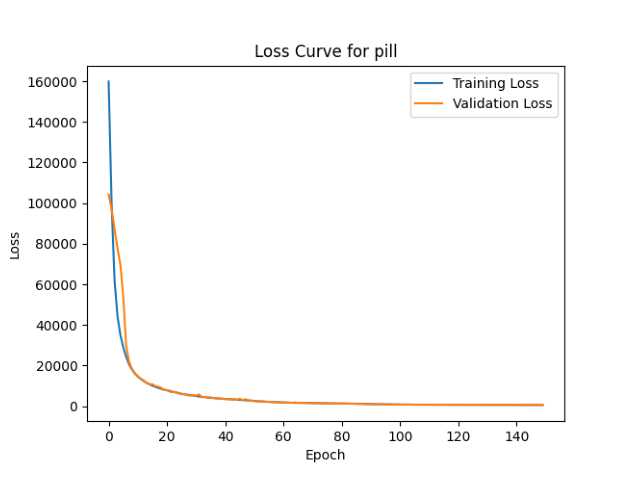

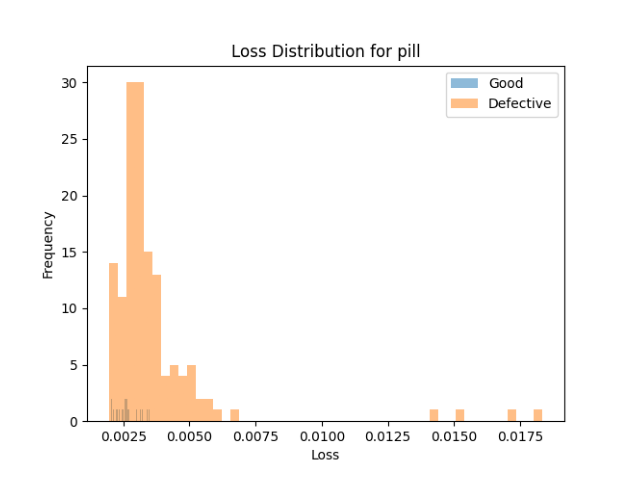

In [ ]:
# Plot and save loss curves
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve for {category}')
plt.show()
plt.close()


# Plot and save loss distributions
plt.figure()
plt.hist(good_losses, bins=50, alpha=0.5, label='Good')
plt.hist(defective_losses, bins=50, alpha=0.5, label='Defective')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'Loss Distribution for {category}')
plt.show()
plt.close()


## For category "toothbrush"

In [ ]:
category = 'toothbrush'
print(f"\nProcessing category: {category}")

# Load training and validation datasets
train_dataset = CustomImageDataset(folder_path=f'./data/train/{category}', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = CustomImageDataset(folder_path=f'./data/val/{category}', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

print("train: ", len(train_dataset))
print("val: ", len(val_dataset))

# Initialize model and optimizer
latent_dim = 512
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=2.5e-4, weight_decay=1e-5)


# Train the model
train_losses, val_losses = train_vae(model, train_loader, val_loader, optimizer, epochs=300)

# Evaluate the model
test_good_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/good', transform=transform)
test_defective_dataset = CustomImageDataset(folder_path=f'./data/test/{category}/error', transform=transform)

test_good_loader = DataLoader(test_good_dataset, batch_size=1, shuffle=False)
test_defective_loader = DataLoader(test_defective_dataset, batch_size=1, shuffle=False)

# Compute losses for good samples
good_losses = []
for data, _ in test_good_loader:
    loss = test_image(data.squeeze(0), model, device)
    good_losses.append(loss)

# Compute losses for defective samples
defective_losses = []
for data, _ in test_defective_loader:
    loss = test_image(data.squeeze(0), model, device)
    defective_losses.append(loss)

# Compute accuracies
good_acc, defective_acc, overall_acc = calculate_separate_accuracy(good_losses, defective_losses)
print(f"{category} Good Accuracy: {good_acc * 100:.2f}%")
print(f"{category} Defective Accuracy: {defective_acc * 100:.2f}%")
print(f"{category} Overall Accuracy: {overall_acc * 100:.2f}%")

overall_accuracy.append(overall_acc)



Processing category: toothbrush
train:  48
val:  12
Epoch: 1 | Train Loss: 179363.1250 | Val Loss: 109776.1016 | LR: 0.000250
Epoch: 2 | Train Loss: 162786.6875 | Val Loss: 108842.6875 | LR: 0.000250
Epoch: 3 | Train Loss: 124912.0391 | Val Loss: 107603.1953 | LR: 0.000250
Epoch: 4 | Train Loss: 102769.1484 | Val Loss: 106240.6016 | LR: 0.000250
Epoch: 5 | Train Loss: 90850.8203 | Val Loss: 104588.2812 | LR: 0.000250
Epoch: 6 | Train Loss: 82938.0156 | Val Loss: 102917.4766 | LR: 0.000250
Epoch: 7 | Train Loss: 72241.5859 | Val Loss: 109031.2422 | LR: 0.000250
Epoch: 8 | Train Loss: 68208.0469 | Val Loss: 118113.6016 | LR: 0.000250
Epoch: 9 | Train Loss: 60512.7344 | Val Loss: 110982.2656 | LR: 0.000250
Epoch: 10 | Train Loss: 54921.5508 | Val Loss: 102221.0703 | LR: 0.000250
Epoch: 11 | Train Loss: 51156.9141 | Val Loss: 95180.9766 | LR: 0.000250
Epoch: 12 | Train Loss: 47078.6719 | Val Loss: 88497.3516 | LR: 0.000250
Epoch: 13 | Train Loss: 42674.0586 | Val Loss: 81571.9766 | LR: 0.

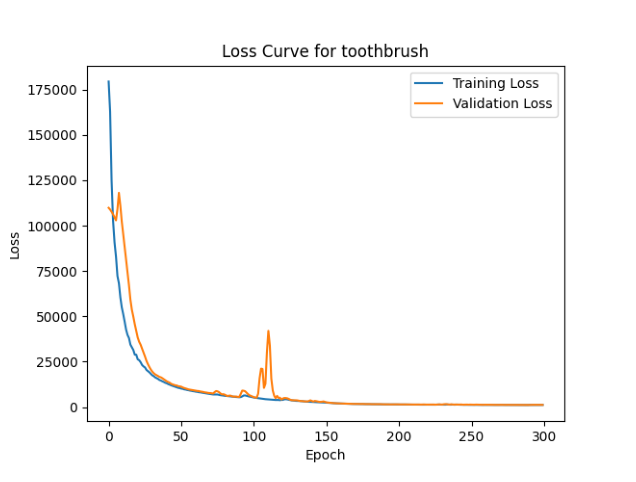

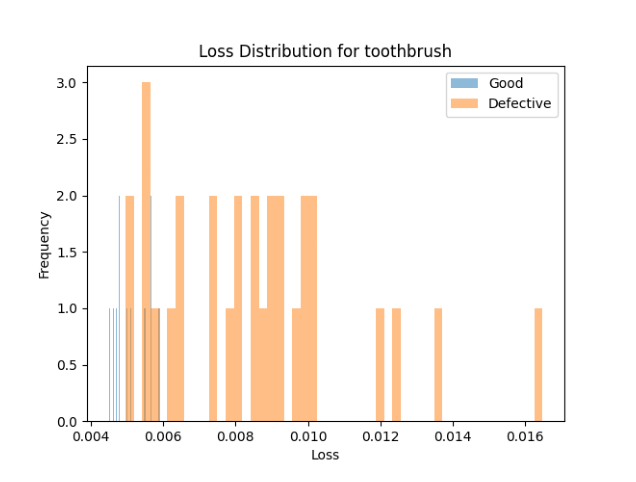

In [ ]:
# Plot and save loss curves
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve for {category}')
plt.show()
plt.close()


# Plot and save loss distributions
plt.figure()
plt.hist(good_losses, bins=50, alpha=0.5, label='Good')
plt.hist(defective_losses, bins=50, alpha=0.5, label='Defective')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'Loss Distribution for {category}')
plt.show()
plt.close()


## Compute overall average accuracy

In [ ]:
mean_accuracy = np.mean(overall_accuracy)
print(f"\nOverall Average Accuracy: {mean_accuracy * 100:.2f}%")


Overall Average Accuracy: 80.21%
